# Fine Tuning do modernBERT

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import sklearn
import transformers
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [2]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [3]:
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn", sklearn.__version__)
print("Transformers:", transformers.__version__)
print("Device:", device)

PyTorch: 2.14.1
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn 1.9.1
Transformers: 5.18.0
Device: mps


In [4]:
df = pd.read_csv(
    "data/imdb-dataset.csv"
)

print(df.shape)
print(df.head())
print(df["sentiment"].value_counts())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
label_map = {
    "negative": 0,
    "positive": 1
}

df["label"] = (
    df["sentiment"]
    .map(label_map)
)

df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [6]:
df = df[
    ["review", "label"]
]

In [7]:
df.head()

,review,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [8]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 40000
Test: 10000


In [9]:
train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df.reset_index(drop=True)
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['review', 'label'],
    num_rows: 40000
})
Dataset({
    features: ['review', 'label'],
    num_rows: 10000
})


In [10]:
MODEL_NAME = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
MAX_LENGTH = 512

def tokenize_function(examples):

    return tokenizer(
        examples["review"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [13]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["review"]
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["review"]
)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [14]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [15]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary"
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [16]:
training_args = TrainingArguments(
    output_dir="./modernbert-imdb",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False
)

In [17]:
per_device_train_batch_size=16

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.144671,0.124070,0.959900,0.951857,0.968800,0.960254
2,0.070216,0.156835,0.959800,0.962948,0.956400,0.959663
3,0.028107,0.204981,0.958100,0.955277,0.961200,0.958229


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7500, training_loss=0.09282070960998536, metrics={'train_runtime': 17011.0099, 'train_samples_per_second': 7.054, 'train_steps_per_second': 0.441, 'total_flos': 4.034427009876614e+16, 'train_loss': 0.09282070960998536, 'epoch': 3.0})

In [20]:
bert_metrics = trainer.evaluate()
bert_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.028107,0.124070,3,0.959900,0.951857,0.968800,0.960254


{'eval_loss': 0.12407028675079346,
 'eval_accuracy': 0.9599,
 'eval_precision': 0.951856946354883,
 'eval_recall': 0.9688,
 'eval_f1': 0.96025374169888}

In [22]:
predictions = trainer.predict(
    tokenized_test
)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = test_df["label"].values

In [23]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "negative",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.97      0.95      0.96      5000
    positive       0.95      0.97      0.96      5000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [25]:
# !pip install matplotlib

In [26]:
MODEL_OUTPUT = "./modernbert-imdb-final"

trainer.save_model(
    MODEL_OUTPUT
)

tokenizer.save_pretrained(
    MODEL_OUTPUT
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modernbert-imdb-final/tokenizer_config.json',
 './modernbert-imdb-final/tokenizer.json')

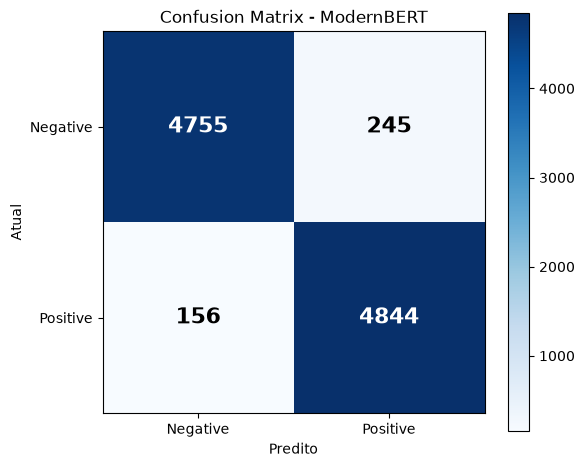

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

# Azul escuro → azul claro
im = ax.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

# Barra de cores
plt.colorbar(im, ax=ax)

# Títulos
ax.set(
    xticks=np.arange(2),
    yticks=np.arange(2),
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    xlabel="Predito",
    ylabel="Atual",
    title="Confusion Matrix - ModernBERT"
)

# Valores dentro das células
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=16,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

# Comparando modernBERT com Jev

In [28]:
from kaggle_imdb_sentimental_analysis import jev_sentiment_classifier

df = pd.read_csv('data/imdb-dataset.csv').sample(n=25000, random_state=1)

df_classif = jev_sentiment_classifier(df)

Classificando reviews:   0%|          | 0/25000 [00:00<?, ?it/s]

In [38]:
df_classif.head()

,review,sentiment,jev_sentiment,jev_confidence,jev_correct,jev_error
26247,With No Dead Heroes you get stupid lines like ...,negative,negative,0.86,True,None
35067,I thought maybe... maybe this could be good. A...,negative,negative,1.0,True,None
34590,An elite American military team which of cours...,negative,negative,1.0,True,None
16668,Ridiculous horror film about a wealthy man (Jo...,negative,negative,1.0,True,None
12196,"Well, if you are one of those Katana's film-nu...",positive,positive,1.0,True,None


In [39]:
print(f"Acurácia Jev = {round(df_classif.jev_correct.value_counts(normalize=True).values[0]*100, 2)} %")
print(f"Acurácia BERT = {round(bert_metrics['eval_accuracy']*100,2)} %")

Acurácia Jev = 96.26 %
Acurácia BERT = 95.99 %
